In [ ]:
# =============================================================================
# SECTION 1: IMPORTS
# =============================================================================
import os
import matplotlib.pyplot as plt
import pandas as pd
import math
import pymer4
import numpy as np
from matplotlib.lines import Line2D
import seaborn as sns
import subprocess
from scipy.stats import (ttest_ind, shapiro, levene, mannwhitneyu, 
                         ttest_1samp, wilcoxon)
from pymer4.models import Lmer
import scipy
import pingouin as pg
from matplotlib import lines as mlines

# =============================================================================
# SECTION 2: UTILITY & PLOTTING FUNCTIONS (COMPLETE)
# =============================================================================

def get_repo_root():
    try:
        repo_root = subprocess.check_output(
            ["git", "rev-parse", "--show-toplevel"], stderr=subprocess.STDOUT
        ).strip().decode("utf-8")
        return repo_root
    except subprocess.CalledProcessError:
        return os.getcwd()

def read_csv_files(directory):
    csv_files = []
    print(f"Checking files in directory: {directory}")
    for filename in os.listdir(directory):
        if filename.startswith("sub") and filename.endswith(".csv"):
            file_path = os.path.join(directory, filename)
            df = pd.read_csv(file_path)
            csv_files.append(df)
    return csv_files

def summarySE(df, measurevar, groupvars, na_rm=True):
    """Compute mean, standard error, and count of observations for each group."""
    grouped = df.groupby(groupvars).agg(
        mean=(measurevar, 'mean'),
        count=(measurevar, 'size'),
        std=(measurevar, 'std')
    ).reset_index()
    
    grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
    
    if na_rm:
        grouped = grouped.dropna()
    
    return grouped

def calculate_summary_rel(df, measurevar, groupvar):
    """
    Calculate mean, standard error, and count for a given measure variable.
    """
    summary = df.groupby(groupvar).agg(
        mean=(measurevar, 'mean'),
        count=(measurevar, 'size'),
        std=(measurevar, 'std')
    ).reset_index()
    summary['stderr'] = summary['std'] / np.sqrt(summary['count'])
    return summary

def wilcoxon_summary(x1, x0, name):
    """
    Mann–Whitney U (rank-sum) for two independent groups.
    Prints U, z (normal approximation), p, and rank-biserial correlation (RBC).
    Numbers are printed with three decimals.
    """
    # Drop missing
    x1 = pd.Series(x1).dropna()
    x0 = pd.Series(x0).dropna()
    n1, n2 = len(x1), len(x0)

    if n1 < 1 or n2 < 1:
        print(f"{name:>3} : not enough data (n1={n1}, n2={n2})")
        return None

    # Mann–Whitney U (independent samples)
    res = mannwhitneyu(x1, x0, alternative='two-sided', use_continuity=False)
    U = float(res.statistic)
    p = float(res.pvalue)

    # Normal approximation for U (no tie correction here)
    mu = n1 * n2 / 2.0
    sigma = math.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
    z = (U - mu) / sigma if sigma > 0 else float('nan')

    rbc = (2 * U) / (n1 * n2) - 1

    print(f"{name:>3} : U = {U:.3f},  z = {z:.3f},  p = {p:.3f},  RBC = {rbc:.3f}")
    return p


def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x, ddof=1)**2 + np.std(y, ddof=1)**2) / 2)

def mwu_with_z(x, y):
    u, p = mannwhitneyu(x, y, alternative='two-sided')
    n1, n0 = len(x), len(y)
    z = (u - n1 * n0 / 2) / np.sqrt(n1 * n0 * (n1 + n0 + 1) / 12)
    return u, z, p

def perform_tests(controls, patients, measure_name):
    """Performs assumption checks and runs t-test or Mann-Whitney U."""
    if len(controls) < 3 or len(patients) < 3:
        print(f"Insufficient data for {measure_name}.")
        return None
    shapiro_controls = shapiro(controls)
    shapiro_patients = shapiro(patients)
    print(f'Shapiro-Wilk for Controls {measure_name}: W={shapiro_controls.statistic:.3f}, p={shapiro_controls.pvalue:.3f}')
    print(f'Shapiro-Wilk for Patients {measure_name}: W={shapiro_patients.statistic:.3f}, p={shapiro_patients.pvalue:.3f}')
    
    levene_test = levene(controls, patients)
    print(f"Levene's Test for {measure_name}: F={levene_test.statistic:.3f}, p={levene_test.pvalue:.3f}")
    
    if (shapiro_controls.pvalue > 0.05 and 
        shapiro_patients.pvalue > 0.05 and 
        levene_test.pvalue > 0.05):
        t_stat, p_value = ttest_ind(controls, patients)
        print(f'--> T-test for {measure_name}: t={t_stat:.3f}, p={p_value:.4f}')
        return p_value
    else:
        u_stat, p_value = mannwhitneyu(controls, patients)
        n1, n2 = len(controls), len(patients)
        z = (u_stat - n1*n2/2.0) / ((n1*n2*(n1+n2+1)/12.0) ** 0.5)
        print(f'--> Mann-Whitney for {measure_name}: U={u_stat:.1f}, z={z:.3f}, p={p_value:.4f}')
    return p_value

def fit_lmer_robustly(base_formula, data, family, random_effects_list):
    """
    Tries to fit an Lmer model with a sequence of random effects structures,
    from most complex to simplest, until one converges.
    
    It uses the 'bobyqa' optimizer and increased iterations for better stability.
    """
    for re_formula in random_effects_list:
        full_formula = f"{base_formula} + {re_formula}"
        print(f"    Trying to fit: {full_formula}")
        
        model = Lmer(full_formula, data=data, family=family)
        model.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
        
        all_warning_strings = [str(s) for vec in model.warnings for s in vec]
        warnings_string = " ".join(all_warning_strings)
        converged_successfully = "failed to converge" not in warnings_string and "degenerate Hessian" not in warnings_string

        if converged_successfully:
            print("    Model converged successfully.")
            if "boundary (singular) fit" in warnings_string:
                print("    Note: Model produced a singular fit warning.")
            return model
        else:
            print("    Model failed to converge. Trying a simpler random effects structure...")
            
    print(f"    All specifications for {base_formula} failed to converge.")
    return model

def add_orthopoly(df, base_col, prefix):
    """
    Create sample-orthogonal polynomial regressors for 'base_col':
    - prefix_op1: orthogonal 'linear' component
    - prefix_op2: orthogonal 'quadratic' component
    Orthogonal to each other and to the intercept on the observed x.
    """
    x = df[base_col].astype(float).to_numpy()
    mask = ~np.isnan(x)
    X = np.column_stack([np.ones_like(x[mask]), x[mask], x[mask]**2])
    Q, _ = np.linalg.qr(X)  # orthonormal basis
    op1 = np.full_like(x, np.nan, dtype=float)
    op2 = np.full_like(x, np.nan, dtype=float)
    op1[mask] = Q[:, 1]
    op2[mask] = Q[:, 2]
    df[f'{prefix}_op1'] = op1
    df[f'{prefix}_op2'] = op2
    
def plot_boxplot(df, y_col, p_value, y_label, title=None, 
                        y_lim_lower=None, y_lim_upper=None, y_ticks=None):
    """
    Generates a flexible boxplot that auto-scales the y-axis just enough
    to fit the significance bracket without overlapping the title.
    """
    plt.figure(figsize=(9, 6))
    
    ax = sns.boxplot(x='patientstatus', y=y_col, data=df,
                     palette={0: control_color, 1: ocd_color},
                     hue='patientstatus', legend=False)
                     
    sns.swarmplot(x='patientstatus', y=y_col, data=df,
                  color=dot_color, dodge=True, ax=ax, marker='o', size=5)
    
    min_val, max_val = df[y_col].min(), df[y_col].max()
    data_range = max_val - min_val if max_val > min_val else 1
    final_lower_lim = y_lim_lower if y_lim_lower is not None else min_val - (data_range * 0.1)

    if y_lim_upper is not None:
        final_upper_lim = y_lim_upper
        bracket_y = final_upper_lim - ((final_upper_lim - final_lower_lim) * 0.15)
    else:
        total_top_padding = data_range * 0.20
        final_upper_lim = max_val + total_top_padding
        bracket_y = max_val + (total_top_padding / 2.0)

    ax.set_ylim(final_lower_lim, final_upper_lim)
    
    significance_text = get_significance_text(p_value)
    draw_significance_bracket(ax, 0, 1, bracket_y, significance_text)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Controls', 'Patients'])
    
    if y_ticks is not None:
        ax.set_yticks(y_ticks)

    if title is None:
        title = f'Average {y_label} Comparison'
    ax.set_title(title)

    ax.set_xlabel('Group')
    ax.set_ylabel(f'Average {y_label}')
    plt.tight_layout()
    plt.show()

def remove_outliers_IQR(df, columns, factor=1.5):
    df = df.copy()
    bad_idx = set()
    bounds = {}
    for col in columns:
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - factor*iqr, q3 + factor*iqr
        bounds[col] = (lo, hi)
        bad_idx |= set(df.index[(df[col] < lo) | (df[col] > hi)])
    outliers = df.loc[sorted(bad_idx)]
    df_clean = df.drop(index=outliers.index)
    return df_clean, outliers


def draw_significance_bracket(ax, x1, x2, y, text, height_percent=0.01):
    height = y * height_percent
    ax.plot([x1, x1, x2, x2], [y, y + height, y + height, y], lw=1.5, color='black')
    ax.plot([x1, x1], [y, y - height], lw=1.5, color='black')
    ax.plot([x2, x2], [y, y - height], lw=1.5, color='black')
    font_tmp = 16 if text == 'n.s.' else 18
    ax.text((x1 + x2) * 0.5, y + height * 1.5, text, ha='center', va='bottom', color='black', fontsize=font_tmp)

def get_significance_text(p_value):
    if p_value is None: return ''
    if p_value < 0.001: return '***'
    elif p_value < 0.01: return '**'
    elif p_value < 0.05: return '*'
    else: return 'n.s.'

def plot_accuracy_boxplot_ax(ax, average_data, p_value_acc):
    """Plots just the accuracy boxplot without the main y-label."""
    sns.boxplot(x='patientstatus', y='average_accuracy', data=average_data,
                palette={'0': control_color, '1': ocd_color},
                ax=ax, width=0.5, linewidth=1.5)
    sns.stripplot(x='patientstatus', y='average_accuracy', data=average_data,
                  color=dot_color, jitter=True, ax=ax, marker='o', size=5)

    ylim = 1.15
    ax.set_ylim(0, ylim)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    significance_text = get_significance_text(p_value_acc)
    draw_significance_bracket(ax, 0, 1, ylim - 0.08, significance_text)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([])
    ax.set_xlabel('Overall', fontsize=16)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=16, left=True, width=1.5)
    ax.tick_params(axis='x', bottom=False)

    # match the line-plot spine weight so the two panels line up
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    sns.despine(ax=ax)


def plot_confidence_boxplot_ax(ax, average_data, p_value_conf):
    """Plots just the confidence boxplot without the main y-label."""
    sns.boxplot(x='patientstatus', y='average_confidence', data=average_data,
                palette={'0': control_color, '1': ocd_color},
                ax=ax, width=0.5, linewidth=1.5, showfliers=False)
    sns.stripplot(x='patientstatus', y='average_confidence', data=average_data,
                  color=dot_color, jitter=True, ax=ax, marker='o', size=5)

    ylim = 120
    ax.set_ylim(0, ylim)
    ax.set_yticks(np.arange(0, 101, 20))
    significance_text = get_significance_text(p_value_conf)
    draw_significance_bracket(ax, 0, 1, ylim - 7, significance_text)

    ax.set_xticks([0, 1])
    ax.set_xticklabels([])
    ax.set_xlabel('Overall', fontsize=16)
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelsize=16, left=True, width=1.5)
    ax.tick_params(axis='x', bottom=False)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    sns.despine(ax=ax)


def plot_mean_var_ax(ax, summary_controls, summary_patients, measurevar, ylabel, xlabel, ylim, yticks, colors):
    summary_controls = pd.DataFrame(summary_controls)
    summary_patients = pd.DataFrame(summary_patients)
    summary_controls['patientstatus'] = 'Controls'
    summary_patients['patientstatus'] = 'Patients'
    
    df_combined = pd.concat([summary_controls, summary_patients], ignore_index=True)
    ax.axvline(0, color=dot_color, linewidth=1, linestyle='--')
    for group_key, color in colors.items():
        label = 'Controls' if group_key == 0 else 'Patients'
        subset = df_combined[df_combined['patientstatus'] == label]
        sns.lineplot(data=subset, x='nTrial_rel', y='mean', color=color, ax=ax)
        sns.scatterplot(data=subset, x='nTrial_rel', y='mean', color=color, edgecolor='white', s=100, label=label, ax=ax)
        ax.errorbar(subset['nTrial_rel'], subset['mean'], yerr=subset['stderr'], fmt='none', color=color, capsize=5)
    
    ax.set_ylim(ylim)
    ax.set_yticks(yticks)
    ax.set_xticks(np.arange(-5, 6, 1))
    
    ax.set_xlabel(xlabel, fontsize=16, fontweight='bold')
    ax.set_ylabel(' ', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax.tick_params(axis='x', labelsize=14, width=1.5, bottom=True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    if measurevar == 'mean_accuracy':
        ax.legend(title='Group', fontsize=14, title_fontsize=14, loc='lower left')
    else:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    sns.despine()

def plot_rt_boxplot_ax(ax, average_data, p_value_rt_log):
    perc95 = np.percentile(average_data['average_RT'], 95)
    ylim = perc95 + (perc95 * 0.1)
    sns.boxplot(x='patientstatus', y='average_RT', data=average_data, palette={'0': control_color, '1': ocd_color}, ax=ax, width=0.3, linewidth=1.5,showfliers=False)
    sns.stripplot(x='patientstatus', y='average_RT', data=average_data, color=dot_color, jitter=True, ax=ax, marker='o', size=5)
    ax.set_ylim(0, ylim)
    significance_text = get_significance_text(p_value_rt_log)
    draw_significance_bracket(ax, 0, 1, ylim - (ylim * 0.07), significance_text)
    
    ax.set_xticks([0.5])
    ax.set_xticklabels(['Overall'])
    ax.set_yticks(np.linspace(0, ylim, 6))
    ax.set_xlabel(' ')
    ax.set_ylabel('Mean Reaction Time (RT)', fontweight='bold', fontsize=16)
    ax.tick_params(axis='both', labelsize=14)
    ax.tick_params(axis='y', left=True, width=1.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    sns.despine(ax=ax)

def prettify_term(term):
    # Handle interaction terms
    if ':' in term:
        parts = term.split(':')
        pretty_parts = [rename_map.get(p, p) for p in parts]
        return " ×\n".join(pretty_parts)
    else:
        return rename_map.get(term, term)

def zscore_within(x):
    """Computes the z-score within each group, avoiding division by zero."""
    m = x.mean()
    s = x.std(ddof=1)
    return (x - m) / s if s > 0 else x - m

# Define colors
ocd_color = '#5f8cff'
control_color = '#b4a854'
dot_color ='#57504d'
regressor_color ="#673C33"
custom_palette = {"0": control_color, "1": ocd_color}

In [ ]:
# =============================================================================
# SECTION 3: DATA LOADING & PREPROCESSING
# =============================================================================

repo_root = get_repo_root()
print("Repository Root:", repo_root)

# Set the directory path
directory = os.path.join(repo_root, "data")

# Call the function and get the list of dataframes
dataframes = read_csv_files(directory)

# Display the first few rows of each DataFrame
for i, df in enumerate(dataframes):
    print(f"First few rows of DataFrame {i+1}:")
    print(df.head())
    print("\n")

# Set directory to the data folder within the repository.
data_dir = os.path.join(repo_root, "data")
os.chdir(data_dir)
# Load data
CrypticCreatures = pd.read_csv("Table_CrypticCreatures_YaleCohort.csv")
CrypticCreatures.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreature_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_YaleCohort.csv")
CrypticCreatures_patients_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_patients_YaleCohort.csv")
CrypticCreatures_patients_relativeShift = CrypticCreatures_patients_relativeShift.sort_values(by=['id', 'nTrial_rel'])
CrypticCreatures_controls_relativeShift = pd.read_csv("Table_CrypticCreaturesShiftRelative_controls_YaleCohort.csv")
CrypticCreatures_controls_relativeShift = CrypticCreatures_controls_relativeShift.sort_values(by=['id', 'nTrial_rel'])

CrypticCreatures_BayesianLearner = pd.read_csv("CrypticCreatures_BayesianLearner.csv")
CrypticCreatures_BayesianLearner = CrypticCreatures_BayesianLearner.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreatures_BayesianLearner_patients_relativeShift = pd.read_csv("CrypticCreaturesBayesianLearner_relativeShift_OCD.csv")
CrypticCreatures_BayesianLearner_patients_relativeShift = CrypticCreatures_BayesianLearner_patients_relativeShift.sort_values(by=['id', 'nTrial_rel'])
CrypticCreatures_BayesianLearner_controls_relativeShift = pd.read_csv("CrypticCreaturesBayesianLearner_relativeShift_controls.csv")
CrypticCreatures_BayesianLearner_controls_relativeShift = CrypticCreatures_BayesianLearner_controls_relativeShift.sort_values(by=['id', 'nTrial_rel'])

In [ ]:
analysis_tasks = {
    'patients': {
        'CrypticCreatures': {
            'df': CrypticCreatures_patients_relativeShift,
            'measures': [
                'mean_accuracy_id', 'mean_accuracy_ed', 'mean_accuracy',
                'mean_confidence_id', 'mean_confidence_ed', 'mean_confidence'
            ]
        },
        'BayesianLearner': {
            'df': CrypticCreatures_BayesianLearner_patients_relativeShift,
            'measures': [
                'entropy', 'sum_prior_chosen_features', 'BLR_confidence',
                'signed_confidence_deviation', 'signed_prior_deviation'
            ]
        }
    },
    'controls': {
        'CrypticCreatures': {
            'df': CrypticCreatures_controls_relativeShift,
            'measures': [
                'mean_accuracy_id', 'mean_accuracy_ed', 'mean_accuracy',
                'mean_confidence_id', 'mean_confidence_ed', 'mean_confidence',
                'mean_RT_id', 'mean_RT_ed', 'mean_RT',
                'mean_RT_log_id', 'mean_RT_log_ed', 'mean_RT_log'
            ]
        },
        'BayesianLearner': {
            'df': CrypticCreatures_BayesianLearner_controls_relativeShift,
            'measures': [
                'entropy', 'sum_prior_chosen_features', 'BLR_confidence',
                'signed_confidence_deviation', 'signed_prior_deviation'
            ]
        }
    }
}

summary_results = {}

print("--- Starting Efficient Summary Calculation ---")

for group_name, tasks in analysis_tasks.items():
    for task_name, task_details in tasks.items():
        input_df = task_details['df']
        for measure_col in task_details['measures']:
            
            # This logic creates your specific variable names
            # e.g., 'mean_accuracy_id' -> 'Cryptic_mean_acc_ID_patients'
            name_part = measure_col.replace('mean_', '').replace('_id', '_ID').replace('_ed', '_ED')
            name_part = name_part.replace('confidence', 'conf').replace('accuracy', 'acc').replace('entropy', 'entr')
            variable_name = f"Cryptic_mean_{name_part}_{group_name}"
            
            print(f"Processing: {variable_name}")
            
            # Run the summary function and store the result in the dictionary
            summary_results[variable_name] = summarySE(input_df, measure_col, ['nTrial_rel'])

print("--- Finished ---")


In [ ]:
# data frames
controls_df = CrypticCreatures_controls_relativeShift 
patients_df = CrypticCreatures_patients_relativeShift

# Merge controls dataset based on 'nTrial_rel' and 'id'
controls_merged_df = pd.merge(
    CrypticCreatures_BayesianLearner_controls_relativeShift,
    controls_df,
    on=['nTrial_rel', 'id'],  
    how='inner'  
)
patients_merged_df = pd.merge(
    CrypticCreatures_BayesianLearner_patients_relativeShift,
    patients_df,
    on=['nTrial_rel', 'id'], 
    how='inner' 
)
measure_vars = [
    'change_in_mean_accuracy', 'change_in_mean_accuracy_abs', 
    'change_in_mean_accuracy_ed', 'change_in_mean_accuracy_abs_ed', 
    'change_in_mean_accuracy_id', 'change_in_mean_accuracy_abs_id',
    'change_in_mean_confidence', 'change_in_mean_confidence_abs',
    'change_in_mean_confidence_ed', 'change_in_mean_confidence_abs_ed',
    'change_in_mean_confidence_id', 'change_in_mean_confidence_abs_id',
    'signed_confidence_deviation','signed_prior_deviation','mean_confidence','BLR_confidence',
    'mean_accuracy','mean_RT_log','mean_RT'
    
]

# Calculate summaries for controls and patients
summary_controls_rel = {var: calculate_summary_rel(controls_merged_df, var, 'nTrial_rel') for var in measure_vars}
summary_patients_rel = {var: calculate_summary_rel(patients_merged_df, var, 'nTrial_rel') for var in measure_vars}

summary_controls_accuracy = summary_controls_rel['change_in_mean_accuracy']
summary_patients_accuracy = summary_patients_rel['change_in_mean_accuracy']


In [ ]:
##############################################################################
# 1)  Run Wilcoxon tests on main table
##############################################################################

df_unique = CrypticCreatures.drop_duplicates(subset='id', keep='first')   # ←── ADDED

print("\nWilcoxon rank‐sum tests (one row per id):")

wilcoxon_summary(
    df_unique.loc[df_unique['patientstatus']==1, 'age'],
    df_unique.loc[df_unique['patientstatus']==0, 'age'],
    name='Age'
)  

wilcoxon_summary(
    df_unique.loc[df_unique['patientstatus']==1, 'icar_totalscore'],
    df_unique.loc[df_unique['patientstatus']==0, 'icar_totalscore'],
    name='IQ'
)  

In [ ]:
# Compute each individual's overall averages for accuracy, confidence, RT, and RT_log
CrypticCreatures['average_accuracy']   = CrypticCreatures.groupby('id')['chosen_outcome'].transform('mean')
CrypticCreatures['average_confidence']   = CrypticCreatures.groupby('id')['confidence'].transform('mean')
CrypticCreatures['average_RT']           = CrypticCreatures.groupby('id')['RT'].transform('mean')
CrypticCreatures['average_RT_log']       = CrypticCreatures.groupby('id')['RT_log'].transform('mean')

# Build a summary DataFrame with one row per subject
average_data = CrypticCreatures[['id', 'average_accuracy', 'average_confidence', 
                                 'average_RT', 'average_RT_log', 'patientstatus']].drop_duplicates()

# Convert patientstatus to integer and split into groups
average_data['patientstatus'] = average_data['patientstatus'].astype(int)
average_data_pat = average_data[average_data['patientstatus'] == 1]
average_data_con = average_data[average_data['patientstatus'] == 0]

# Remove outliers separately for controls and patients (across all measures)
cols_to_check = ['average_accuracy', 'average_confidence', 'average_RT', 'average_RT_log']
average_data_con_clean, outliers_con = remove_outliers_IQR(average_data_con, cols_to_check)
average_data_pat_clean, outliers_pat = remove_outliers_IQR(average_data_pat, cols_to_check)

# Combine cleaned data for overall analysis
average_data_clean = pd.concat([average_data_con_clean, average_data_pat_clean])

p_value_acc    = perform_tests(average_data_con_clean['average_accuracy'],
                                average_data_pat_clean['average_accuracy'], 'Accuracy')
p_value_conf   = perform_tests(average_data_con_clean['average_confidence'],
                                average_data_pat_clean['average_confidence'], 'Confidence')
p_value_rt     = perform_tests(average_data_con_clean['average_RT'],
                                average_data_pat_clean['average_RT'], 'RT')
p_value_rt_log = perform_tests(average_data_con_clean['average_RT_log'],
                                average_data_pat_clean['average_RT_log'], 'RT_log')
print("P-values after outlier removal:")
print(f"Accuracy: {p_value_acc}")
print(f"Confidence: {p_value_conf}")
print(f"RT: {p_value_rt}")
print(f"RT (log): {p_value_rt_log}")

print("Prior to outlier removal:")
p_value_acc  = perform_tests(average_data_con['average_accuracy'],
                              average_data_pat['average_accuracy'], 'Accuracy')
p_value_conf = perform_tests(average_data_con['average_confidence'],
                              average_data_pat['average_confidence'], 'Confidence')
p_value_rt = perform_tests(average_data_con['average_RT'],
                           average_data_pat['average_RT'], 'RT')
p_value_rt_log = perform_tests(average_data_con['average_RT_log'],
                               average_data_pat['average_RT_log'], 'RT_log')
print(f"Accuracy: {p_value_acc}")
print(f"Confidence: {p_value_conf}")
print(f"RT: {p_value_rt}")
print(f"RT (log): {p_value_rt_log}")



In [ ]:
# ===========
# Repeated Measures ANOVA for Task-Specific Analysis
# ===========
rm_data = CrypticCreatures.groupby(['id','task_id','patientstatus'], observed=True).agg(
    average_accuracy   = ('chosen_outcome', 'mean'),
    average_confidence = ('confidence', 'mean'),
    average_RT         = ('RT', 'mean'),
    average_RT_log     = ('RT_log', 'mean'),
    average_repet_err_ed = ('repet_err_ed', 'mean')
).reset_index()

rm_data['patientstatus'] = rm_data['patientstatus'].astype('category')

measures = {
    'average_accuracy': 'Accuracy',
    'average_confidence': 'Confidence',
    'average_RT': 'RT',
    'average_RT_log': 'RT (log)',
    'average_repet_err_ed': 'Repetitive Error'
}

print("\n========== Repeated Measures ANOVA Results ==========\n")
for measure_col, measure_label in measures.items():
    aov = pg.mixed_anova(dv=measure_col, between='patientstatus', within='task_id',
                         subject='id', data=rm_data)
    print(f"Repeated Measures ANOVA for {measure_label}:")
    print(aov, "\n")

# ===========
# Task-Specific Posthoc Analysis after rmANOVA 
# ===========
for task in sorted(rm_data['task_id'].unique()):
    print(f"\n===== Analysis for Task ID: {task} =====")
    
    average_data_task = rm_data[rm_data['task_id'] == task].copy()

    average_data_task['patientstatus'] = average_data_task['patientstatus'].astype(int)
    task_con = average_data_task[average_data_task['patientstatus'] == 0]
    task_pat = average_data_task[average_data_task['patientstatus'] == 1]
    
    cols_to_check_task = list(measures.keys())
    task_con_clean, _ = remove_outliers_IQR(task_con, cols_to_check_task, factor=1.5)
    task_pat_clean, _ = remove_outliers_IQR(task_pat, cols_to_check_task, factor=1.5)
    average_data_task_clean = pd.concat([task_con_clean, task_pat_clean])
    
    print(f"\n--- Descriptive Statistics for Task ID: {task} ---")
    for col, label in measures.items():
        mean_con = task_con_clean[col].mean()
        sd_con = task_con_clean[col].std()
        mean_pat = task_pat_clean[col].mean()
        sd_pat = task_pat_clean[col].std()
        print(f"{label}: M_controls={mean_con:.3f}, SD_controls={sd_con:.3f}; M_OCD={mean_pat:.3f}, SD_OCD={sd_pat:.3f}")

Summary Stats After Incorrect vs. Correct Trials etc

In [ ]:
# Sort and compute previous trial outcome and change in confidence
CrypticCreatures = CrypticCreatures.sort_values(by=['id', 'task_id', 'run', 'trial'])
CrypticCreatures['prev_outcome'] = CrypticCreatures.groupby('id')['chosen_outcome'].shift(1)
if 'confidence_change' not in CrypticCreatures.columns:
    CrypticCreatures['confidence_change'] = CrypticCreatures.groupby('id')['confidence'].diff()

# Mark trials based on the previous trial's outcome and filter
CrypticCreatures['trial_type'] = np.where(
    CrypticCreatures['prev_outcome'] == 1, 'after_correct',
    np.where(CrypticCreatures['prev_outcome'] == 0, 'after_incorrect', None)
)
df_marked = CrypticCreatures.dropna(subset=['trial_type', 'confidence_change'])

avg_change = df_marked.groupby(['id', 'trial_type'])['confidence_change'].mean().reset_index()
avg_change_pivot = avg_change.pivot(index='id', columns='trial_type', values='confidence_change').reset_index()

patient_info = CrypticCreatures.groupby('id')['patientstatus'].first().reset_index()
avg_change_pivot = pd.merge(avg_change_pivot, patient_info, on='id')
avg_change_pivot['patientstatus'] = avg_change_pivot['patientstatus'].astype(str)

controls_pivot = avg_change_pivot[avg_change_pivot['patientstatus'] == '0']
patients_pivot = avg_change_pivot[avg_change_pivot['patientstatus'] == '1']
print(f"Data ready. Found {len(controls_pivot)} controls and {len(patients_pivot)} patients.")

# After Correct Trials
controls_correct_raw = controls_pivot['after_correct'].dropna()
patients_correct_raw = patients_pivot['after_correct'].dropna()

# After Incorrect Trials
controls_incorrect_raw = controls_pivot['after_incorrect'].dropna()
patients_incorrect_raw = patients_pivot['after_incorrect'].dropna()

# --- Cleaned Data (After Outlier Removal) ---check

# After Correct Trials
controls_correct_clean_df, _ = remove_outliers_IQR(pd.DataFrame(controls_correct_raw), ['after_correct'])
patients_correct_clean_df, _ = remove_outliers_IQR(pd.DataFrame(patients_correct_raw), ['after_correct'])
c_correct_clean = controls_correct_clean_df['after_correct']
p_correct_clean = patients_correct_clean_df['after_correct']

# After Incorrect Trials
controls_incorrect_clean_df, _ = remove_outliers_IQR(pd.DataFrame(controls_incorrect_raw), ['after_incorrect'])
patients_incorrect_clean_df, _ = remove_outliers_IQR(pd.DataFrame(patients_incorrect_raw), ['after_incorrect'])
c_incorrect_clean = controls_incorrect_clean_df['after_incorrect']
p_incorrect_clean = patients_incorrect_clean_df['after_incorrect']

p_correct = patients_correct_raw
c_correct = controls_correct_raw
p_incorrect = patients_incorrect_raw
c_incorrect = controls_incorrect_raw

# =============================================================================
# --- 2. Within-Group Comparisons (vs. Zero) ---
# =============================================================================
print("\n" + "="*60)
print("Within-Group Tests: Is the average change different from zero?")
print("="*60)

# --- After Correct Trials ---
print("\n--- After Correct Trials ---")
stat_p_corr, pval_p_corr = ttest_1samp(p_correct, popmean=0)
print(f"OCD: t({len(p_correct)-1}) = {stat_p_corr:.3f}, p = {pval_p_corr:.4f}")

stat_c_corr, pval_c_corr = wilcoxon(c_correct, zero_method='pratt')
print(f"Controls (Wilcoxon): W = {stat_c_corr:.1f}, p = {pval_c_corr:.4f}")

# --- After Incorrect Trials ---
print("\n--- After Incorrect Trials ---")
stat_p_incorr, pval_p_incorr = ttest_1samp(p_incorrect, popmean=0)
print(f"OCD: t({len(p_incorrect)-1}) = {stat_p_incorr:.3f}, p = {pval_p_incorr:.4f}")

stat_c_incorr, pval_c_incorr = wilcoxon(c_incorrect, zero_method='pratt')
print(f"Controls (Wilcoxon): W = {stat_c_incorr:.1f}, p = {pval_c_incorr:.4f}")

# =============================================================================
# --- 3. Between-Group Comparisons ---
# =============================================================================
print("\n" + "="*60)
print("Between-Group Tests: Is there a difference between OCD and Controls?")
print("="*60)
# --- After Correct Trials ---
mwu_correct = pg.mwu(p_correct, c_correct, alternative='two-sided')
u_val_correct = mwu_correct['U-val'].iloc[0]
p_val_correct = mwu_correct['p-val'].iloc[0]
rbc_correct = mwu_correct['RBC'].iloc[0] 
print(f"After Correct: Mann-Whitney U = {u_val_correct:.1f}, p = {p_val_correct:.4f}, RBC = {rbc_correct:.3f}")

# --- After Incorrect Trials ---
mwu_incorrect = pg.mwu(p_incorrect, c_incorrect, alternative='two-sided')
u_val_incorrect = mwu_incorrect['U-val'].iloc[0]
p_val_incorrect = mwu_incorrect['p-val'].iloc[0]
rbc_incorrect = mwu_incorrect['RBC'].iloc[0] 
print(f"After Incorrect: Mann-Whitney U = {u_val_incorrect:.1f}, p = {p_val_incorrect:.4f}, RBC = {rbc_incorrect:.3f}")

num_tests = 2

p_val_correct_bonferroni = min(1.0, p_val_correct * num_tests) 
p_val_incorrect_bonferroni = min(1.0, p_val_incorrect * num_tests)

significance_incorrect = p_val_incorrect_bonferroni 
significance_correct = p_val_correct_bonferroni

In [ ]:
# Use the behavioral (not BayesianLearner) relative-shift tables — they have mean_RT
relshift = pd.concat([
    CrypticCreatures_patients_relativeShift.assign(patientstatus=1),
    CrypticCreatures_controls_relativeShift.assign(patientstatus=0),
])

# ----- Position-wise post-shift tests (trials 1 and 2) -----
print("Position-wise post-shift tests:")
for pos in [1, 2]:
    sub = relshift[relshift['nTrial_rel'] == pos]
    a_ocd = sub.loc[sub['patientstatus'] == 1, 'mean_accuracy'].dropna()
    a_con = sub.loc[sub['patientstatus'] == 0, 'mean_accuracy'].dropna()
    r_ocd = sub.loc[sub['patientstatus'] == 1, 'mean_RT'].dropna()
    r_con = sub.loc[sub['patientstatus'] == 0, 'mean_RT'].dropna()
    if pos == 1:
        u, _, p = mwu_with_z(a_con, a_ocd)           
        print(f"  Trial {pos} accuracy: U={u:.1f}, p={p:.4f}, d={cohens_d(a_ocd, a_con):.3f}")
    else:
        t, p = ttest_ind(a_con, a_ocd)               
        print(f"  Trial {pos} accuracy: t={t:.3f}, p={p:.4f}, d={cohens_d(a_ocd, a_con):.3f}")
    u, _, p = mwu_with_z(r_con, r_ocd)                
    print(f"  Trial {pos} RT: U={u:.1f}, p={p:.4f}, d={cohens_d(r_ocd, r_con):.3f}")

# ----- Confidence drop at shift (Cohen's d for trial -1 → +1) -----
pre  = relshift[relshift['nTrial_rel'] == -1]
post = relshift[relshift['nTrial_rel'] ==  1]
drop_df = pre.merge(post[['id', 'patientstatus', 'mean_confidence']],
                    on=['id', 'patientstatus'], suffixes=('_pre', '_post'))
drop_df['drop'] = drop_df['mean_confidence_post'] - drop_df['mean_confidence_pre']
ocd_drop = drop_df.loc[drop_df['patientstatus'] == 1, 'drop'].dropna()
con_drop = drop_df.loc[drop_df['patientstatus'] == 0, 'drop'].dropna()
print(f"\nConfidence drop at shift: Cohen's d = {cohens_d(ocd_drop, con_drop):.3f}")

# ----- Feedback sensitivity (Cohen's d, within-group W, between-group U) -----
print("\nFeedback sensitivity:")
print(f"  After Correct  : d = {cohens_d(p_correct, c_correct):.3f}")
print(f"  After Incorrect: d = {cohens_d(p_incorrect, c_incorrect):.3f}")

w_corr,   p_w_corr   = wilcoxon(p_correct)
w_incorr, p_w_incorr = wilcoxon(p_incorrect)
print(f"\nOCD within-group Wilcoxon signed-rank:")
print(f"  After Correct  : W={w_corr:.1f}, p={p_w_corr:.4f}")
print(f"  After Incorrect: W={w_incorr:.1f}, p={p_w_incorr:.4f}")

u_corr,   z_corr,   p_u_corr   = mwu_with_z(p_correct, c_correct)
u_incorr, z_incorr, p_u_incorr = mwu_with_z(p_incorrect, c_incorrect)
print(f"\nBetween-group Mann-Whitney U:")
print(f"  After Correct  : U={u_corr:.1f}, z={z_corr:.3f}, p={p_u_corr:.4f}")
print(f"  After Incorrect: U={u_incorr:.1f}, z={z_incorr:.3f}, p={p_u_incorr:.4f}")


Mixed-Effects Models

In [ ]:
# ===========================================
# 1. Create the .sc variables
# ===========================================
CrypticCreatures['confidence.sc'] = CrypticCreatures.groupby('id')['confidence'].transform(zscore_within)

for col, new_col in [('age', 'age.sc'), ('icar_totalscore', 'total_iq.sc')]:
    if col in CrypticCreatures.columns:
        CrypticCreatures[new_col] = (CrypticCreatures[col] - CrypticCreatures[col].mean()) / CrypticCreatures[col].std(ddof=1)

# ===========================================
# 2. Ensure categorical variables are of type 'category'
# ===========================================
categorical_columns = ['patientstatus', 'chosen_outcome_shift', 'task_id', 'IDs', 'EDs', 'ruleChange']
if 'gender' in CrypticCreatures.columns:
    categorical_columns.append('gender')
for col in categorical_columns:
    CrypticCreatures[col] = CrypticCreatures[col].astype(str).astype('category')

# ===========================================
# 3. Create General Shift Variable
# ===========================================
CrypticCreatures['general_shift'] = (CrypticCreatures['ruleChange'].astype(float) > 0).astype(str).astype('category')

# ===========================================
# 4. Create Shifted Variables (Lagged Values)
# ===========================================
shift_vars = ['confidence.sc', 'confidence_change_abs', 'confidence_change']
for var in shift_vars:
    CrypticCreatures[f'{var}_shift'] = CrypticCreatures.groupby('id')[var].shift(1)
for var in ['IDs','EDs','general_shift']:
    CrypticCreatures[f'{var}_shiftback'] = (
        CrypticCreatures.groupby('id')[var].shift(1).astype('category')
    )

# ===========================================
# Build log & orthogonal polynomial terms
#       (replaces the old "+1 + polyval" block)
# ===========================================

# Use raw centered distances for linear/quadratic; reserve +1 only for log()
for base in ['distance_toShift', 'distance_toED', 'distance_toID']:
    # log term (avoid log(0))
    CrypticCreatures[f'log_{base}'] = np.log(CrypticCreatures[base].astype(float) + 1)
    # orthogonal polynomials on the observed x
    add_orthopoly(CrypticCreatures, base, base)

# Replace the string "nan" with an actual NaN
CrypticCreatures = CrypticCreatures.replace("nan", np.nan)

CrypticCreatures_accmodel = CrypticCreatures.dropna(subset=['chosen_outcome_shift'])

for col in ['patientstatus', 'chosen_outcome_shift', 'task_id'] + (['gender'] if 'gender' in CrypticCreatures.columns else []):
    CrypticCreatures[col] = CrypticCreatures[col].cat.remove_unused_categories()

for col in ['patientstatus', 'chosen_outcome_shift', 'task_id'] + (['gender'] if 'gender' in CrypticCreatures.columns else []):
    print(f"{col} levels:", list(CrypticCreatures[col].cat.categories))

factors = {col: list(CrypticCreatures[col].cat.categories) for col in ['patientstatus', 'chosen_outcome_shift', 'task_id']}
if 'gender' in CrypticCreatures.columns:
    factors['gender'] = list(CrypticCreatures['gender'].cat.categories)
print("Factors dictionary:", factors)


Accuracy models

In [ ]:
modelAccRule = Lmer("chosen_outcome ~ general_shift_shiftback*patientstatus + age.sc + gender + total_iq.sc + task_id + (general_shift_shiftback|id) + (1|task_id)",
             data=CrypticCreatures, family="binomial")
resultAccRule = modelAccRule.fit(old_optimizer=True)
print(f'accuracy model general rule shift:', resultAccRule)

In [ ]:
# =============================================================================
# Accuracy ~ general rule shift (main model)
# =============================================================================

modelAccRule = Lmer(
    "chosen_outcome ~ general_shift_shiftback * patientstatus "
    "+ age.sc + gender + total_iq.sc + task_id "
    "+ (1 | id) + (1 | task_id)",
    data=CrypticCreatures.dropna(subset=['general_shift_shiftback']),
    family="binomial",
)
modelAccRule.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
print(modelAccRule.summary())


In [ ]:
# =============================================================================
# ICAR effect on overall accuracy
# =============================================================================

modelAccRuleCheck = Lmer(
    "chosen_outcome ~ general_shift_shiftback * patientstatus "
    "+ general_shift_shiftback * total_iq.sc "
    "+ age.sc + gender + task_id "
    "+ (1 | id) + (1 | task_id)",
    data=CrypticCreatures.dropna(subset=['general_shift_shiftback']),
    family="binomial",
)
modelAccRuleCheck.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
print(modelAccRuleCheck.summary())


In [ ]:
# Post-shift recovery × ICAR (ID and ED shifts)
id_data = CrypticCreatures[CrypticCreatures['distance_toID'] > 0].copy()
ed_data = CrypticCreatures[CrypticCreatures['distance_toED'] > 0].copy()

model_id_icar = Lmer(
    "chosen_outcome ~ log_distance_toID * patientstatus "
    "+ log_distance_toID * total_iq.sc "
    "+ age.sc + gender + task_id "
    "+ (log_distance_toID | id) + (1 | task_id)",
    data=id_data, family="binomial",
)
model_id_icar.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
print("ID recovery + ICAR:")
print(model_id_icar.summary())

model_ed_icar = Lmer(
    "chosen_outcome ~ log_distance_toED * patientstatus "
    "+ log_distance_toED * total_iq.sc "
    "+ age.sc + gender + task_id "
    "+ (log_distance_toED | id) + (1 | task_id)",
    data=ed_data, family="binomial",
)
model_ed_icar.fit(control="optimizer='bobyqa', optCtrl=list(maxfun=2e5)")
print("\nED recovery + ICAR:")
print(model_ed_icar.summary())


Confidence models

In [ ]:
generalShiftModel = Lmer('confidence ~ general_shift_shiftback*patientstatus + age.sc + gender + total_iq.sc + task_id+(1+general_shift_shiftback | id) + (1 | task_id)', 
                   data=CrypticCreatures, 
                   family='gaussian')
resultGeneralShiftModel = generalShiftModel.fit(old_optimizer=True)
print(resultGeneralShiftModel)

model_confidence_interaction = Lmer('confidence ~ patientstatus*chosen_outcome_shift + age.sc + gender + total_iq.sc +task_id+ (chosen_outcome_shift | id) + (1 | task_id)', 
                      data=CrypticCreatures, 
                      family='gaussian')
resultConfAccModel = model_confidence_interaction.fit(old_optimizer=True)
print(resultConfAccModel)

Models - Distance to Shift (incl. comparison)

In [ ]:
# Models - Distance to Shift (incl. comparison)
# ============================

# 1) Define predictors
shift_configs = {
    "General Shift": {
        "linear": "distance_toShift",     
        "poly1":  "distance_toShift_op1", 
        "poly2":  "distance_toShift_op2", 
        "log":    "log_distance_toShift"
    },
    "ED Shift": {
        "linear": "distance_toED",
        "poly1":  "distance_toED_op1",
        "poly2":  "distance_toED_op2",
        "log":    "log_distance_toED"
    },
    "ID Shift": {
        "linear": "distance_toID",
        "poly1":  "distance_toID_op1",
        "poly2":  "distance_toID_op2",
        "log":    "log_distance_toID"
    }
}

y_vars = ["chosen_outcome", "RT_log", "confidence"]
all_models = {y: {} for y in y_vars}

# 2) Model fitting loop
for y in y_vars:
    print(f"\nFitting models for Dependent Variable: {y}")
    family_type = "binomial" if y == "chosen_outcome" else "gaussian"

    for shift_name, var_names in shift_configs.items():
        print(f"  - Analyzing predictor: {shift_name}")

        # subset to rows where the linear distance exists (for ED/ID)
        if shift_name == "General Shift":
            current_data = CrypticCreatures
        else:
            current_data = CrypticCreatures.dropna(subset=[var_names['linear']])

        # --- Linear Model (raw distance) ---
        lin = var_names['linear']
        base_formula_lin = f"{y} ~ {lin}"
        random_effects_lin = [
            f"(1 + {lin} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Linear"] = fit_lmer_robustly(
            base_formula_lin, current_data, family_type, random_effects_lin
        )

        # --- Quadratic Model (orthogonal op1/op2) ---
        p1 = var_names['poly1']
        p2 = var_names['poly2']
        base_formula_quad = f"{y} ~ {p1} + {p2}"
        random_effects_quad = [
            f"(1 + {p1} + {p2} | id) + (1 | task_id)",
            f"(1 + {p2} | id) + (1 | task_id)",
            f"(1 + {p1} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Quadratic"] = fit_lmer_robustly(
            base_formula_quad, current_data, family_type, random_effects_quad
        )

        # --- Log Model ---
        lvar = var_names['log']
        base_formula_log = f"{y} ~ {lvar}"
        random_effects_log = [
            f"(1 + {lvar} | id) + (1 | task_id)",
            f"(1 | id) + (1 | task_id)"
        ]
        all_models[y][f"{shift_name} - Log"] = fit_lmer_robustly(
            base_formula_log, current_data, family_type, random_effects_log
        )

# 3) Model Comparison using BIC
for y in y_vars:
    print(f"\n{'='*62}")
    print(f"==================== Model Comparison for: `{y}` ====================")
    print(f"{'='*62}")

    for shift_name in shift_configs.keys():
        print(f"--- Predictor: {shift_name} (Lower BIC is better) ---")
        model_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]

        results = []
        for name in model_names:
            mdl = all_models[y].get(name, None)
            if mdl is not None and hasattr(mdl, 'BIC'):
                results.append({'Name': name, 'BIC': mdl.BIC})

        if results:
            best_model_info = min(results, key=lambda x: x['BIC'])
            header = f"{'Model':<30} {'BIC':>12}"
            print(header)
            print("-" * len(header))
            for res in results:
                print(f"{res['Name']:<30} {res['BIC']:>12.3f}")
            print(f"\n  >>> Best model for {shift_name}: {best_model_info['Name']}\n")
        else:
            print(f"No converged models found for {shift_name}\n")

# 4) Print Full Summaries of Winning Models
print(f"\n\n{'='*70}")
print("="*20 + " SUMMARIES OF WINNING MODELS " + "="*21)
print(f"{'='*70}\n")

for y in y_vars:
    for shift_name in shift_configs.keys():
        model_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]
        results = []
        for name in model_names:
            mdl = all_models[y].get(name, None)
            if mdl is not None and hasattr(mdl, 'BIC'):
                results.append({'Name': name, 'BIC': mdl.BIC})
        if not results:
            continue

        best_model_info = min(results, key=lambda x: x['BIC'])
        best_model_name = best_model_info['Name']
        winning_model = all_models[y][best_model_name]

        print(f"\n--- WINNING MODEL FOR: {y} ~ {shift_name} ---")
        print(f"    (Model Type: {best_model_name.split(' - ')[-1]})")
        if winning_model is not None:
            print(winning_model.summary())
        else:
            print("    ERROR: Winning model object not found.")


Follow-Up Models (post distance to shift)

In [ ]:
# Follow-Up Models (post distance to shift)
# ============================================================
# Refit each BIC-winning (y, shift) model WITH interaction (patientstatus)
# ============================================================

if 'patientstatus' not in CrypticCreatures.columns:
    raise ValueError("Column 'patientstatus' is missing from CrypticCreatures.")
CrypticCreatures['patientstatus'] = CrypticCreatures['patientstatus'].astype('category')

interaction_models = {y: {} for y in y_vars}

for y in y_vars:
    print(f"\nAdding group interaction for dependent variable: {y}")
    family_type = "binomial" if y == "chosen_outcome" else "gaussian"

    for shift_name, var_names in shift_configs.items():
        candidate_names = [f"{shift_name} - Linear", f"{shift_name} - Quadratic", f"{shift_name} - Log"]
        results = []
        for nm in candidate_names:
            mdl = all_models.get(y, {}).get(nm, None)
            if (mdl is not None) and hasattr(mdl, "BIC"):
                results.append([nm, mdl.BIC])
        if len(results) == 0:
            print(f"  - {shift_name}: No converged base model to augment; skipping.")
            continue

        # pick the base winner
        best_idx = 0
        for i in range(1, len(results)):
            if results[i][1] < results[best_idx][1]:
                best_idx = i
        best_name = results[best_idx][0]
        best_bic  = results[best_idx][1]
        model_type = best_name.split(" - ")[-1]  # "Linear" | "Quadratic" | "Log"

        lin  = var_names['linear']
        p1   = var_names['poly1']
        p2   = var_names['poly2']
        lvar = var_names['log']

        # Use same data selection convention
        if shift_name == "General Shift":
            current_data = CrypticCreatures.copy()
        else:
            current_data = CrypticCreatures.dropna(subset=[lin]).copy()

        # Build fixed-effect formula with interaction(s)
        if model_type == "Linear":
            fe_rhs = f"{lin} * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {lin} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]
        elif model_type == "Quadratic":
            fe_rhs = f"({p1} + {p2}) * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {p1} + {p2} | id) + (1 | task_id)",
                f"(1 + {p2} | id) + (1 | task_id)",
                f"(1 + {p1} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]
        else:  # "Log"
            fe_rhs = f"{lvar} * patientstatus + age.sc + gender + total_iq.sc"
            random_effects = [
                f"(1 + {lvar} | id) + (1 | task_id)",
                f"(1 | id) + (1 | task_id)"
            ]

        formula = f"{y} ~ {fe_rhs}"

        print(f"  - {shift_name}: base winner = {best_name} (BIC={best_bic:.3f})")
        print(f"    Refit WITH interaction using:  {formula}")

        model_int = fit_lmer_robustly(formula, current_data, family_type, random_effects)
        interaction_models[y][f"{shift_name} - {model_type} * group"] = model_int

        base_model = all_models[y][best_name]
        base_bic_print = base_model.BIC if (base_model is not None and hasattr(base_model, "BIC")) else float("nan")
        int_bic_print  = model_int.BIC   if (model_int  is not None and hasattr(model_int,  "BIC")) else float("nan")
        print(f"    BIC (base) = {base_bic_print:.3f}   |   BIC (with interaction) = {int_bic_print:.3f}")

        if model_int is not None:
            print("    --- Interaction model summary ---")
            try:
                print(model_int.summary())
            except Exception as e:
                print(f"    (Could not print summary: {e})")


Figures for Main Manuscript & Supplemental Information

In [ ]:
# Figure 2 - Main Manuscript
plt.rcParams.update({'font.size': 16})

# ============
# (2) Create the Combined Figure with 2 Rows
# ============
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 10),
    dpi=100,
    gridspec_kw={'width_ratios': [1, 2], 'wspace': 0},
)

# --- Row 0: Accuracy ---
plot_accuracy_boxplot_ax(axes[0, 0], average_data, p_value_acc)
plot_mean_var_ax(
    axes[0, 1],
    summary_controls_rel['mean_accuracy'],
    summary_patients_rel['mean_accuracy'],
    'mean_accuracy', 'Mean Accuracy', ' ',
    (0, 1.15), np.arange(0, 1.01, 0.2),
    colors={0: control_color, 1: ocd_color},
)
axes[0, 0].text(-0.1, 1.1, 'A', transform=axes[0, 0].transAxes,
                fontsize=20, fontweight='bold', va='top', ha='right')

# --- Row 1: Confidence ---
plot_confidence_boxplot_ax(axes[1, 0], average_data, p_value_conf)
plot_mean_var_ax(
    axes[1, 1],
    summary_controls_rel['mean_confidence'],
    summary_patients_rel['mean_confidence'],
    'mean_confidence', 'Mean Confidence', 'Trial (0=Shifts)',
    (20, 120), np.arange(20, 101, 20),
    colors={0: control_color, 1: ocd_color},
)
axes[1, 0].text(-0.1, 1.1, 'B', transform=axes[1, 0].transAxes,
                fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.subplots_adjust(wspace=0)   

if not os.path.exists('../figures'):
    os.makedirs('../figures')

plt.savefig('../figures/Fig2_AccConf_Average.png', dpi=100, bbox_inches='tight')
plt.show()


/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_95507/1241326473.py:121: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_95507/1241326473.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_95507/1241326473.py:162: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axC.set_xticklabels([" ", " "], fontsize=16)
/var/folders/x2/gjzbvwgd1fx38_r04b_wdn0r0000gn/T/ipykernel_95507/1241326473.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same ef

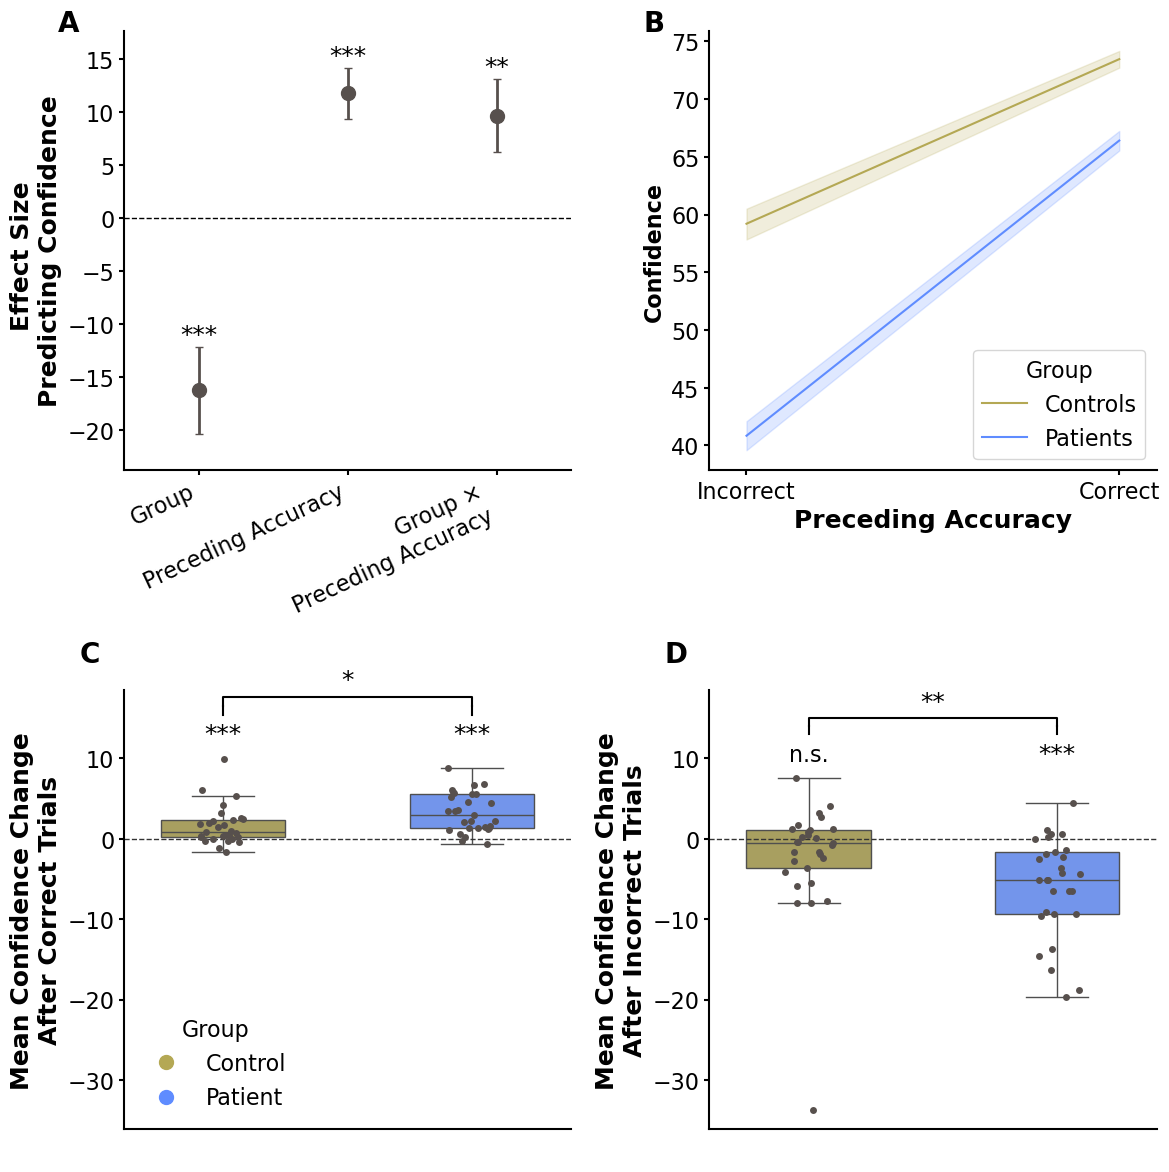

In [ ]:
#Figure 3 - Main Manuscript
# -------------------------------
sort_cols = ['id']
for col in ['task_id', 'run', 'trial']:
    if col in CrypticCreatures.columns:
        sort_cols.append(col)
CrypticCreatures = CrypticCreatures.sort_values(by=sort_cols)
CrypticCreatures['trial_all'] = CrypticCreatures.groupby('id').cumcount() + 1

CrypticCreatures['prev_outcome'] = CrypticCreatures.groupby('id')['chosen_outcome'].shift(1)

CrypticCreatures['trial_type'] = np.where(
    CrypticCreatures['prev_outcome'] == 1, 'after_correct',
    np.where(CrypticCreatures['prev_outcome'] == 0, 'after_incorrect', None)
)
df_marked = CrypticCreatures.dropna(subset=['trial_type'])

avg_change = (
    df_marked.groupby(['id', 'trial_type'])['confidence_change']
    .mean()
    .reset_index()
)
avg_change_pivot = avg_change.pivot(index='id', columns='trial_type', values='confidence_change').reset_index()
if 'nan' in avg_change_pivot.columns:
    avg_change_pivot = avg_change_pivot.drop('nan', axis=1)

patient_info = CrypticCreatures.groupby('id')['patientstatus'].first().reset_index()
avg_change_pivot = pd.merge(avg_change_pivot, patient_info, on='id')

# =============================================================================
# Regression coefficients prep (Panel A)
# =============================================================================
coefs_confPlot = model_confidence_interaction.coefs.copy()
coefs_confPlot.index = coefs_confPlot.index.astype(str)
for intercept in ['(Intercept)', 'Intercept']:
    if intercept in coefs_confPlot.index:
        coefs_confPlot = coefs_confPlot.drop(intercept)
demographics = ["age.sc", "gender", "total_iq.sc", 'task_id']
pattern = '|'.join(demographics)
coefs_confPlot = coefs_confPlot[~coefs_confPlot.index.str.contains(pattern)]
rename_map = {
    "patientstatus1": "Group",
    "chosen_outcome_shift1.0": "Preceding Accuracy",
    "confidence": "Confidence",
}
coefs_confPlot['Pretty'] = [prettify_term(term) for term in coefs_confPlot.index]

custom_palette = {'0': control_color, '1': ocd_color}
custom_palette_b = {0: control_color, 1: ocd_color}
offset = 0.5
x_positions = np.arange(len(coefs_confPlot)) + offset

# =============================================================================
# Per-box p-values: one-sample Wilcoxon of confidence_change vs 0 in each group
# =============================================================================
avg_change_pivot['patientstatus'] = avg_change_pivot['patientstatus'].astype(str)
GROUP_ORDER = ['0', '1']                          

def _onesample_p(values):
    values = pd.Series(values).dropna()
    if len(values) < 3 or (values == 0).all():
        return None
    try:
        return wilcoxon(values).pvalue
    except ValueError:
        return None

p_C_ctrl = _onesample_p(avg_change_pivot.loc[avg_change_pivot['patientstatus']=='0', 'after_correct'])
p_C_pat  = _onesample_p(avg_change_pivot.loc[avg_change_pivot['patientstatus']=='1', 'after_correct'])
p_D_ctrl = _onesample_p(avg_change_pivot.loc[avg_change_pivot['patientstatus']=='0', 'after_incorrect'])
p_D_pat  = _onesample_p(avg_change_pivot.loc[avg_change_pivot['patientstatus']=='1', 'after_incorrect'])

# =============================================================================
# Create Combined Figure: 2 Rows x 2 Columns
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# ----------------------------
# TOP ROW (Panels A & B)
# ----------------------------
axA = axes[0, 0]
axA.errorbar(
    x_positions, coefs_confPlot['Estimate'], yerr=coefs_confPlot['SE'],
    fmt='o', color=dot_color, ecolor=dot_color, elinewidth=2, capsize=3, markersize=10,
)
axA.axhline(0, linestyle='--', color='black', linewidth=1)
axA.set_xticks(x_positions)
axA.set_xticklabels(coefs_confPlot['Pretty'], rotation=25, ha='right', fontsize=16)
axA.set_ylabel('Effect Size \nPredicting Confidence', fontsize=18, fontweight="bold")
axA.set_xlim(0, max(x_positions) + offset)
axA.margins(y=0.1)
axA.spines['top'].set_visible(False)
axA.spines['right'].set_visible(False)
axA.tick_params(axis='y', labelsize=16, width=1.5, left=True)
axA.tick_params(axis='x', labelsize=16, width=1.5, bottom=True)
axA.spines['left'].set_linewidth(1.5)
axA.spines['bottom'].set_linewidth(1.5)
axA.text(-0.1, 1.05, "A", transform=axA.transAxes,
         fontsize=20, fontweight="bold", va="top", ha="right")
for x, (_, row) in zip(x_positions, coefs_confPlot.iterrows()):
    p_val = row['P-val']
    sig = get_significance_text(p_val)
    y = row['Estimate'] + row['SE']
    axA.text(x, y, sig, ha='center', va='bottom', fontsize=18, color='black')

axB = axes[0, 1]
sns.lineplot(
    x="chosen_outcome_shift", y="confidence", hue="patientstatus",
    data=CrypticCreatures, palette=custom_palette, ci=95,
    markers=True, dashes=False, ax=axB,
)
axB.spines['top'].set_visible(False)
axB.spines['right'].set_visible(False)
axB.tick_params(axis='y', left=True, width=1.5)
axB.set_xlim(-0.1, 1.1)
axB.set_xlabel("Preceding Accuracy", fontsize=18, fontweight='bold')
axB.set_ylabel("Confidence", fontsize=16, fontweight='bold')
axB.set_xticks([0, 1])
axB.set_xticklabels(["Incorrect", "Correct"], fontsize=14)
axB.tick_params(axis='x', labelsize=16, width=1.5, bottom=True)
axB.spines['left'].set_linewidth(1.5)
axB.spines['bottom'].set_linewidth(1.5)
handles, labels = axB.get_legend_handles_labels()
legend_map = {"0": "Controls", "1": "Patients"}
new_labels = [legend_map.get(label, label) for label in labels]
axB.legend(handles, new_labels, title="Group", loc="lower right", fontsize=16, title_fontsize=16)
axB.text(-0.1, 1.05, "B", transform=axB.transAxes,
         fontsize=20, fontweight="bold", va="top", ha="right")

# ----------------------------
# BOTTOM ROW (Panels C & D)
# ----------------------------
axC = axes[1, 0]
sns.boxplot(
    data=avg_change_pivot, x='patientstatus', y='after_correct',
    palette=custom_palette, order=GROUP_ORDER,           
    ax=axC, showfliers=False, width=0.5,
)
sns.stripplot(
    data=avg_change_pivot, x='patientstatus', y='after_correct',
    color=dot_color, size=5, jitter=True, order=GROUP_ORDER,  
    ax=axC,
)
axC.set_xlim(-0.4, 1.4)
axC.axhline(y=0, linestyle="--", color="#333333", linewidth=1)
axC.set_xlabel("")
axC.set_ylabel("Mean Confidence Change\nAfter Correct Trials", fontsize=18, fontweight="bold")
axC.set_xticklabels([" ", " "], fontsize=16)
axC.tick_params(axis='y', labelsize=16)
axC.tick_params(axis='x', bottom=False)
axC.tick_params(axis='y', left=True, width=1.5)
axC.spines['top'].set_visible(False)
axC.spines['right'].set_visible(False)
axC.spines['left'].set_linewidth(1.5)
axC.spines['bottom'].set_linewidth(1.5)
sns.despine(ax=axC)
axC.text(-0.1, 1.05, "C", transform=axC.transAxes,
         fontsize=20, fontweight="bold", va="bottom", ha="left")

axD = axes[1, 1]
sns.boxplot(
    data=avg_change_pivot, x='patientstatus', y='after_incorrect',
    palette=custom_palette, order=GROUP_ORDER,          
    ax=axD, showfliers=False, width=0.5,
)
sns.stripplot(
    data=avg_change_pivot, x='patientstatus', y='after_incorrect',
    color=dot_color, size=5, jitter=True, order=GROUP_ORDER,
    ax=axD,
)
axD.set_xlim(-0.4, 1.4)
axD.axhline(y=0, linestyle="--", color="#333333", linewidth=1)
axD.set_xlabel("")
axD.set_ylabel("Mean Confidence Change\nAfter Incorrect Trials", fontsize=18, fontweight="bold")
axD.set_xticklabels([" ", " "], fontsize=16)
axD.tick_params(axis='y', labelsize=16)
axD.tick_params(axis='x', bottom=False)
axD.tick_params(axis='y', left=True, width=1.5)
axD.spines['top'].set_visible(False)
axD.spines['right'].set_visible(False)
axD.spines['left'].set_linewidth(1.5)
axD.spines['bottom'].set_linewidth(1.5)
sns.despine(ax=axD)
axD.text(-0.1, 1.05, "D", transform=axD.transAxes,
         fontsize=20, fontweight="bold", va="bottom", ha="left")

panelC_top = avg_change_pivot['after_correct'].max()
panelD_top = avg_change_pivot['after_incorrect'].max()

def _label_box(ax, x, p, y):
    if p is None:
        return
    sig = get_significance_text(p)
    fontsize = 16 if sig == 'n.s.' else 18
    ax.text(x, y, sig, ha='center', va='bottom', fontsize=fontsize, color='black')

_label_box(axC, 0, p_C_ctrl, panelC_top + 1.5)
_label_box(axC, 1, p_C_pat,  panelC_top + 1.5)
_label_box(axD, 0, p_D_ctrl, panelD_top + 1.5)
_label_box(axD, 1, p_D_pat,  panelD_top + 1.5)

y_bracket_C = panelC_top + 6.5
y_bracket_D = panelD_top + 6.5

if significance_correct is not None:
    sig_text = get_significance_text(significance_correct)
    draw_significance_bracket(axC, 0, 1, y_bracket_C, sig_text, height_percent=0.07)

if significance_incorrect is not None:
    sig_textB = get_significance_text(significance_incorrect)
    draw_significance_bracket(axD, 0, 1, y_bracket_D, sig_textB, height_percent=0.07)

control_patch = mlines.Line2D([], [], color=control_color, marker="o", linestyle="None", markersize=10, label="Control")
patient_patch = mlines.Line2D([], [], color=ocd_color, marker="o", linestyle="None", markersize=10, label="Patient")
axC.legend(handles=[control_patch, patient_patch], title='Group', fontsize=16, title_fontsize=16, loc='lower left')

overall_top = max(y_bracket_C, y_bracket_D) + 2
common_ylim = [
    min(axC.get_ylim()[0], axD.get_ylim()[0]),
    overall_top,
]
axC.set_ylim(common_ylim)
axD.set_ylim(common_ylim)

plt.tight_layout()
axC.get_legend().set_frame_on(False)
plt.savefig('../figures/Fig3_Combined_Narrow.png')


Supplemental Information

RT Mixed Models

In [ ]:
rtShiftModelGroup = Lmer('RT_log ~ general_shift_shiftback * patientstatus + age.sc + gender + total_iq.sc +task_id+ (general_shift_shiftback | id) + (1 | task_id)', 
                    data=CrypticCreatures, 
                    family='gaussian')
resultRTShiftModelGroup = rtShiftModelGroup.fit(old_optimizer=True)
print(resultRTShiftModelGroup)

In [ ]:
model_rt_acc = Lmer('RT_log ~ patientstatus*chosen_outcome_shift + age.sc + gender + total_iq.sc +task_id+ (chosen_outcome_shift | id) + (1 | task_id)', 
                      data=CrypticCreatures, 
                      family='gaussian')
resultRTAccModel = model_rt_acc.fit(old_optimizer=True)
print(resultRTAccModel)

RT Figure (Supplemental Information)

In [ ]:
# # --- Supplemental RT Figure---
fig, axes = plt.subplots(
    1, 2,               
    figsize=(10, 5),      
    dpi=100,
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0} 
)

# --- Row 0: RT ---
plot_rt_boxplot_ax(axes[0], average_data, p_value_rt_log)
plot_mean_var_ax(axes[1], 
                 summary_controls_rel['mean_RT'], 
                 summary_patients_rel['mean_RT'], 
                 'mean_RT', 'Mean Reaction Time (RT)', 'Trial (0=Shifts)',
                 (0, 1), np.linspace(0, np.percentile(average_data['average_RT'], 95) * 1.1, 6), 
                 colors={0: control_color, 1: ocd_color})

axes[1].legend(title='Group', fontsize=14, title_fontsize=14, loc='lower left')

axes[0].text(-0.1, 1.1, ' ', transform=axes[0].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()

if not os.path.exists('../figures'):
    os.makedirs('../figures')

plt.savefig('../figures/FigS1_RT_Average.png', dpi=100)
plt.show()